# Convolutional neural networks for image classification

A fully connected network treats an image as a flat list of numbers: it does not know that neighbouring pixels belong together, and a cat in the top-left corner looks completely different from the same cat in the bottom-right. **Convolutional networks** build two assumptions into the architecture:

- **locality**: each unit looks only at a small patch of the image (a 3 × 3 window);
- **weight sharing**: the same filter is slid over the whole image, so a pattern is recognized wherever it appears.

Pooling layers progressively reduce the resolution, so deeper layers see larger regions and more abstract patterns.

On **CIFAR-10** (60,000 colour images of 32 × 32 pixels in 10 classes) we compare:

1. a fully connected network, as a baseline;
2. a simple CNN;
3. a deeper CNN with **batch normalization**, **dropout** and **data augmentation**,

and then look inside the network: learned filters, feature maps, and the errors it still makes.

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset

torch.manual_seed(0)
np.random.seed(0)
torch.set_num_threads(16)
plt.rcParams["figure.dpi"] = 100

## 1. The data

We load CIFAR-10 from the Hugging Face hub and keep all images in memory as tensors (about 180 MB), which makes training on a CPU much faster than decoding images on the fly. The last 5,000 training images are held out as a validation set; the 10,000 test images are used only at the end.

train (45000, 3, 32, 32), validation (5000, 3, 32, 32), test (10000, 3, 32, 32)
images per class (train): [4500, 4486, 4487, 4470, 4520, 4551, 4489, 4485, 4495, 4517]


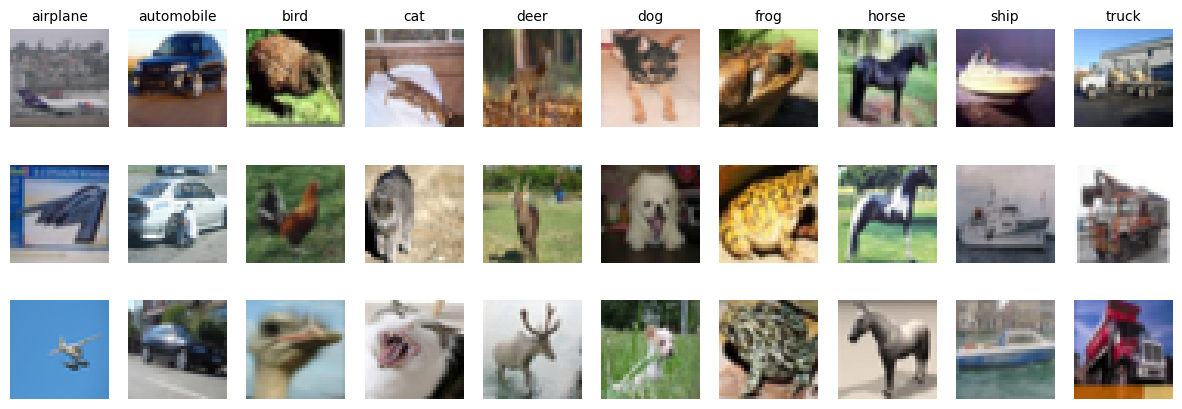

In [2]:
cifar = load_dataset("uoft-cs/cifar10")
classes = cifar["train"].features["label"].names

def to_tensors(split):
    images = torch.from_numpy(np.stack([np.asarray(img) for img in split["img"]])).permute(0, 3, 1, 2)
    return images, torch.tensor(split["label"])

X_all, y_all = to_tensors(cifar["train"])
X_test, y_test = to_tensors(cifar["test"])
X_train, y_train, X_val, y_val = X_all[:45_000], y_all[:45_000], X_all[45_000:], y_all[45_000:]
print(f"train {tuple(X_train.shape)}, validation {tuple(X_val.shape)}, test {tuple(X_test.shape)}")
print("images per class (train):", np.bincount(y_train.numpy()).tolist())

fig, axes = plt.subplots(3, 10, figsize=(15, 5))
for c in range(10):
    for r, i in enumerate(torch.where(y_train == c)[0][:3]):
        axes[r, c].imshow(X_train[i].permute(1, 2, 0))
        axes[r, c].axis("off")
    axes[0, c].set_title(classes[c], fontsize=10)
plt.show()

The ten classes are balanced. The images are tiny and varied: objects appear at different scales, positions and orientations, with cluttered backgrounds. Some classes are visually close (cat and dog, automobile and truck, deer and horse).

Each colour channel is normalized with the mean and standard deviation computed on the **training** images only, so that no information from the validation or test sets leaks into training.

In [3]:
mean = (X_train.float() / 255).mean(dim=(0, 2, 3)).view(1, 3, 1, 1)
std = (X_train.float() / 255).std(dim=(0, 2, 3)).view(1, 3, 1, 1)
print("channel means:", mean.flatten().numpy().round(3), " stds:", std.flatten().numpy().round(3))

def prepare(x):
    return ((x.float() / 255) - mean) / std

def augment(x):
    """Random horizontal flip and random crop with 4 pixels of padding, applied to a batch."""
    flip = torch.rand(len(x)) < 0.5
    x = torch.where(flip.view(-1, 1, 1, 1), x.flip(3), x)
    padded = F.pad(x, (4, 4, 4, 4), mode="reflect")
    i, j = np.random.randint(0, 9, size=2)
    return padded[:, :, i:i + 32, j:j + 32]

channel means: [0.491 0.482 0.446]  stds: [0.247 0.243 0.261]


## 2. Training and evaluation

All models share the same loop: Adam optimizer, cross-entropy loss, mini-batches of 128 images, and the validation accuracy recorded after every epoch. The model state with the best validation accuracy is kept.

In [4]:
def accuracy(model, X, y, batch=1000):
    model.eval()
    with torch.no_grad():
        preds = torch.cat([model(prepare(X[i:i + batch])).argmax(1) for i in range(0, len(X), batch)])
    return (preds == y).float().mean().item()

def train(model, epochs, lr=1e-3, use_augmentation=False, batch_size=128):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history, best_acc, best_state = [], 0.0, None
    start = time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        perm = torch.randperm(len(X_train))
        total, correct = 0.0, 0
        for k in range(0, len(perm), batch_size):
            idx = perm[k:k + batch_size]
            x = prepare(X_train[idx])
            if use_augmentation:
                x = augment(x)
            optimizer.zero_grad()
            logits = model(x)
            loss = F.cross_entropy(logits, y_train[idx])
            loss.backward()
            optimizer.step()
            total += loss.item() * len(idx)
            correct += (logits.argmax(1) == y_train[idx]).sum().item()
        scheduler.step()
        val_acc = accuracy(model, X_val, y_val)
        history.append({"epoch": epoch, "train loss": total / len(perm), "train accuracy": correct / len(perm), "val accuracy": val_acc})
        if val_acc > best_acc:
            best_acc, best_state = val_acc, {k: v.clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)
    print(f"{epochs} epochs in {(time.time() - start) / 60:.1f} min, best validation accuracy {best_acc:.1%}")
    return pd.DataFrame(history).set_index("epoch")

n_params = lambda m: sum(p.numel() for p in m.parameters())

### Baseline: a fully connected network

In [5]:
torch.manual_seed(0)
mlp = nn.Sequential(nn.Flatten(), nn.Linear(3 * 32 * 32, 512), nn.ReLU(), nn.Dropout(0.2),
                    nn.Linear(512, 256), nn.ReLU(), nn.Linear(256, 10))
print(f"parameters: {n_params(mlp):,}")
hist_mlp = train(mlp, epochs=10)

parameters: 1,707,274


10 epochs in 1.2 min, best validation accuracy 55.5%


### A simple CNN

Two convolutional layers (32 and 64 filters of size 3 × 3), each followed by ReLU and 2 × 2 max pooling, then a small fully connected classifier.

In [6]:
torch.manual_seed(0)
simple_cnn = nn.Sequential(
    nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),     # 32 x 16 x 16
    nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),    # 64 x 8 x 8
    nn.Flatten(), nn.Linear(64 * 8 * 8, 128), nn.ReLU(), nn.Linear(128, 10),
)
print(f"parameters: {n_params(simple_cnn):,}")
hist_simple = train(simple_cnn, epochs=10)

parameters: 545,098


10 epochs in 4.1 min, best validation accuracy 72.7%


### A deeper, regularized CNN

Three blocks, each made of two 3 × 3 convolutions with **batch normalization** and GELU activations, followed by max pooling and dropout. Batch normalization re-centres and re-scales the activations of every layer during training, which keeps the optimization well conditioned and allows deeper networks to train quickly. A final global average pooling replaces the large fully connected layer. Training uses **data augmentation** (random flips and shifted crops), so the network never sees exactly the same image twice.

In [7]:
def conv_block(c_in, c_out, dropout):
    return nn.Sequential(
        nn.Conv2d(c_in, c_out, 3, padding=1), nn.BatchNorm2d(c_out), nn.GELU(),
        nn.Conv2d(c_out, c_out, 3, padding=1), nn.BatchNorm2d(c_out), nn.GELU(),
        nn.MaxPool2d(2), nn.Dropout(dropout),
    )

torch.manual_seed(0)
deep_cnn = nn.Sequential(
    conv_block(3, 32, 0.1),       # 32 x 16 x 16
    conv_block(32, 64, 0.2),      # 64 x 8 x 8
    conv_block(64, 128, 0.3),     # 128 x 4 x 4
    nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(128, 10),
)
print(f"parameters: {n_params(deep_cnn):,}")
hist_deep = train(deep_cnn, epochs=15, use_augmentation=True)

parameters: 289,194


15 epochs in 21.0 min, best validation accuracy 85.3%


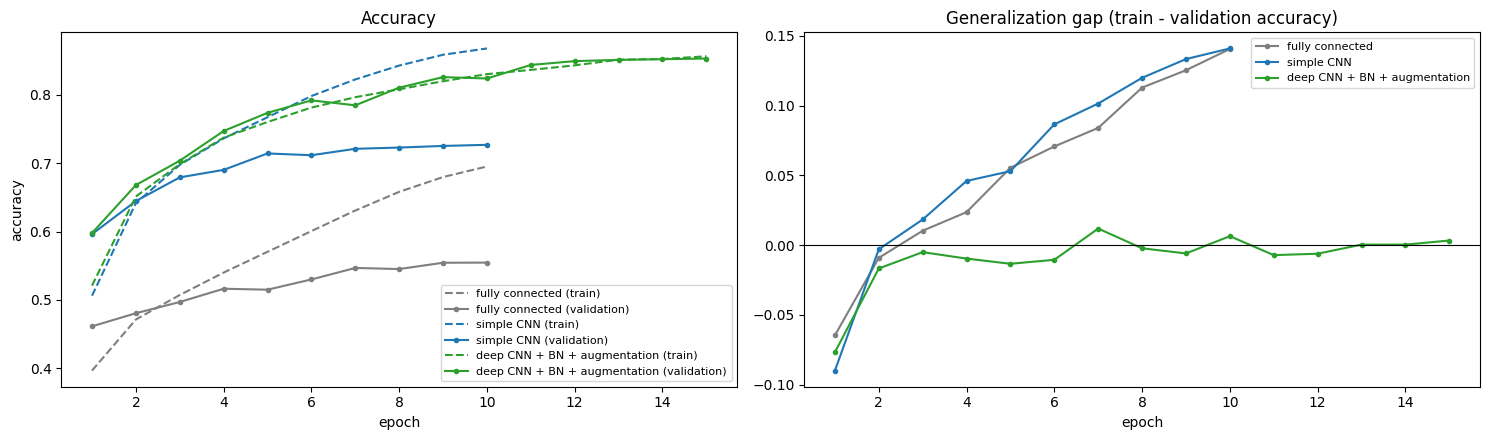

,parameters,best validation accuracy,test accuracy
fully connected,1707274,0.555,0.564
simple CNN,545098,0.727,0.731
deep CNN + BN + augmentation,289194,0.853,0.859


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.5))
for name, hist, color in [("fully connected", hist_mlp, "tab:grey"), ("simple CNN", hist_simple, "tab:blue"), ("deep CNN + BN + augmentation", hist_deep, "tab:green")]:
    ax1.plot(hist.index, hist["train accuracy"], "--", color=color, label=f"{name} (train)")
    ax1.plot(hist.index, hist["val accuracy"], "-o", ms=3, color=color, label=f"{name} (validation)")
    ax2.plot(hist.index, hist["train accuracy"] - hist["val accuracy"], "-o", ms=3, color=color, label=name)
ax1.set(title="Accuracy", xlabel="epoch", ylabel="accuracy")
ax1.legend(fontsize=8)
ax2.axhline(0, color="black", lw=0.8)
ax2.set(title="Generalization gap (train - validation accuracy)", xlabel="epoch")
ax2.legend(fontsize=8)
fig.tight_layout()
plt.show()

summary = pd.DataFrame({
    name: {"parameters": n_params(m), "best validation accuracy": h["val accuracy"].max(), "test accuracy": accuracy(m, X_test, y_test)}
    for name, m, h in [("fully connected", mlp, hist_mlp), ("simple CNN", simple_cnn, hist_simple), ("deep CNN + BN + augmentation", deep_cnn, hist_deep)]
}).T
summary["parameters"] = summary["parameters"].astype(int)
summary.round(3)

The three models tell a clear story:

- The **fully connected** network has the most parameters (1.7 million) and the worst accuracy, about 56% on the test set. Its training accuracy keeps climbing while the validation accuracy stalls: it memorizes pixels instead of learning patterns.
- The **simple CNN**, with a third of the parameters, reaches about 73%. It too overfits quickly: after a few epochs the gap between training and validation accuracy grows steadily, to 14 points after 10 epochs.
- The **deep CNN** with batch normalization, dropout and augmentation reaches about **86%** with only 290,000 parameters, six times fewer than the fully connected network. Its training and validation accuracies stay together for all 15 epochs: augmentation and dropout make memorization much harder, so the network has to learn features that generalize.

The validation and test accuracies agree closely for all three models, so the validation set gave a reliable picture. The price of the deep network is computation: it takes about three times longer per epoch than the simple CNN, because every 3 × 3 filter is applied at every position of large feature maps.

## 3. Looking inside the network

### First-layer filters

The 32 filters of the first layer are small 3 × 3 × 3 colour patches. Rescaled for display, they show what the network looks for at the pixel level.

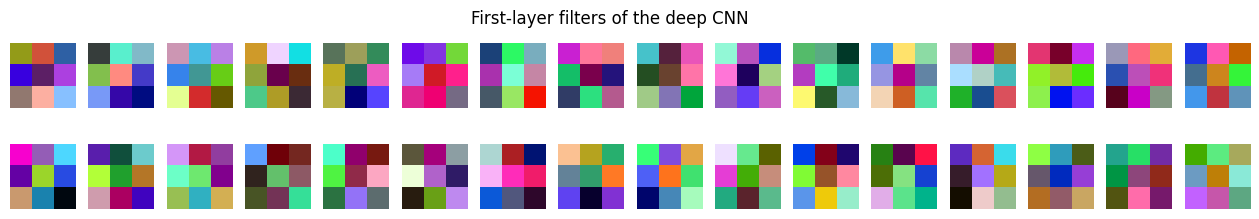

In [9]:
w = deep_cnn[0][0].weight.detach()
w = (w - w.amin(dim=(1, 2, 3), keepdim=True)) / (w.amax(dim=(1, 2, 3), keepdim=True) - w.amin(dim=(1, 2, 3), keepdim=True))
fig, axes = plt.subplots(2, 16, figsize=(16, 2.4))
for ax, f in zip(axes.flat, w):
    ax.imshow(f.permute(1, 2, 0))
    ax.axis("off")
fig.suptitle("First-layer filters of the deep CNN")
plt.show()

With only 3 × 3 pixels and three colour channels, the filters cannot form complex shapes. They look noisier than the clean edge detectors often shown for large networks, but most of them are **colour-contrast** patterns: a bright patch of one hue next to a dark patch or a complementary colour, which respond to coloured edges and blobs. Because batch normalization follows each convolution, the overall scale of a filter does not matter, only its pattern.

### Feature maps

Applying the network to an image and looking at the activations after each block shows how the representation evolves: from edges at full resolution to coarse maps that light up on whole object parts.

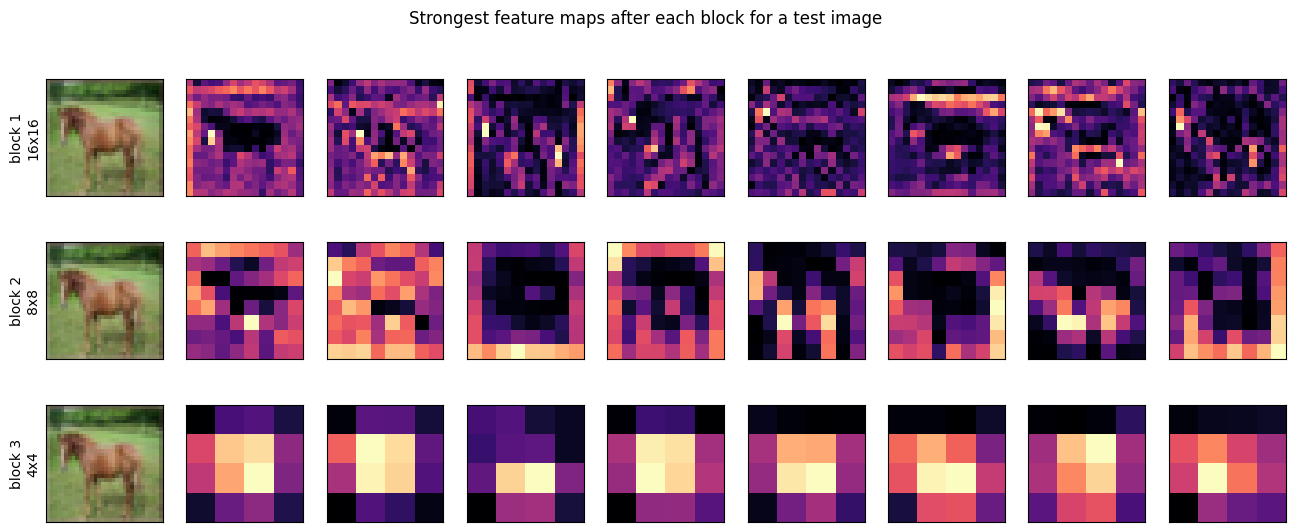

In [10]:
image_idx = int(torch.where(y_test == classes.index("horse"))[0][3])
x = prepare(X_test[image_idx:image_idx + 1])
deep_cnn.eval()
activations = []
with torch.no_grad():
    h = x
    for block in deep_cnn[:3]:
        h = block(h)
        activations.append(h[0])

fig, axes = plt.subplots(3, 9, figsize=(16, 6))
for row, act in enumerate(activations):
    axes[row, 0].imshow(X_test[image_idx].permute(1, 2, 0))
    axes[row, 0].set_ylabel(f"block {row + 1}\n{act.shape[1]}x{act.shape[2]}")
    strongest = act.mean(dim=(1, 2)).argsort(descending=True)[:8]
    for col, ch in enumerate(strongest, start=1):
        axes[row, col].imshow(act[ch], cmap="magma")
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Strongest feature maps after each block for a test image")
plt.show()

### Which classes are confused?

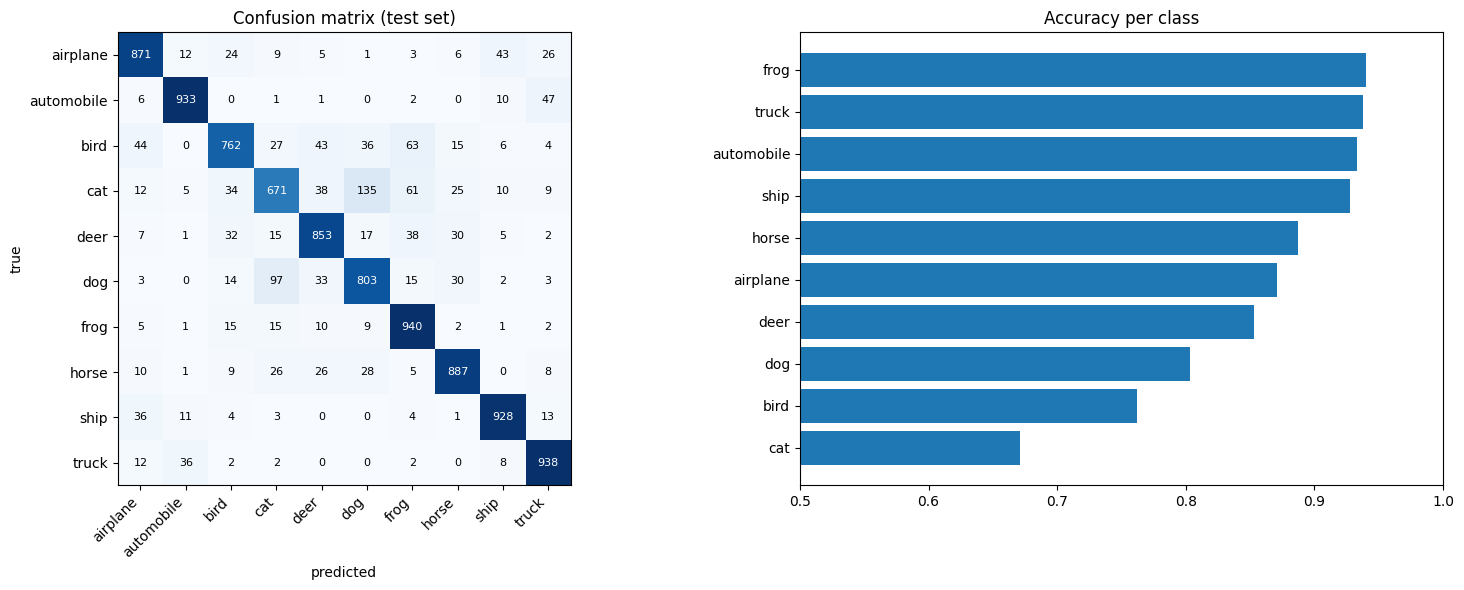

Most frequent confusions (true -> predicted):
true        predicted
cat         dog          135
dog         cat           97
bird        frog          63
cat         frog          61
automobile  truck         47
bird        airplane      44


In [11]:
deep_cnn.eval()
with torch.no_grad():
    logits = torch.cat([deep_cnn(prepare(X_test[i:i + 1000])) for i in range(0, len(X_test), 1000)])
preds = logits.argmax(1)
confusion = pd.crosstab(pd.Series(y_test.numpy(), name="true").map(dict(enumerate(classes))),
                        pd.Series(preds.numpy(), name="predicted").map(dict(enumerate(classes))))
confusion = confusion.loc[classes, classes]
per_class = pd.Series(np.diag(confusion) / confusion.sum(1), index=classes).sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1.4, 1]})
im = ax1.imshow(confusion, cmap="Blues")
ax1.set_xticks(range(10), classes, rotation=45, ha="right")
ax1.set_yticks(range(10), classes)
for i in range(10):
    for j in range(10):
        ax1.text(j, i, confusion.iloc[i, j], ha="center", va="center", fontsize=8, color="white" if confusion.iloc[i, j] > 500 else "black")
ax1.set(title="Confusion matrix (test set)", xlabel="predicted", ylabel="true")
ax2.barh(per_class.index, per_class.values, color="tab:blue")
ax2.set(title="Accuracy per class", xlim=(0.5, 1))
fig.tight_layout()
plt.show()

off = confusion.where(~np.eye(10, dtype=bool)).stack().sort_values(ascending=False).head(6)
print("Most frequent confusions (true -> predicted):")
print(off.astype(int).to_string())

The errors are far from uniform. **Cats** are the hardest class (67% correct), and the single largest confusion is cat ↔ dog (135 cats called dogs, 97 dogs called cats): small furry animals with similar poses and backgrounds. Birds are confused with frogs and airplanes (small objects against sky or grass), and automobiles with trucks. Vehicles, frogs and ships, with distinctive shapes or backgrounds, are recognized more than 92% of the time.

## Summary

- **Convolutions** exploit the spatial structure of images through locality and weight sharing. They reach much higher accuracy than fully connected networks with fewer parameters.
- **Batch normalization**, **dropout** and **data augmentation** let a deeper network train faster and generalize better; augmentation in particular keeps the gap between training and validation accuracy small.
- The first layer learns small **colour-contrast** detectors; deeper layers respond to larger, more abstract patterns at lower resolution, concentrating on the object rather than the background.
- The remaining errors concentrate on **visually similar classes**, especially among animals.